In [57]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [58]:
df=pd.read_csv('placement.csv')

In [59]:
df

,cgpa,placement_exam_marks,placed
0,7.19,26.0,1
1,7.46,38.0,1
2,7.54,40.0,1
3,6.42,8.0,1
4,7.23,17.0,0
...,...,...,...
995,8.87,44.0,1
996,9.12,65.0,1
997,4.89,34.0,0
998,8.62,46.0,1


C:\Users\User\AppData\Local\Temp\ipykernel_16768\3213958968.py:4: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `kdeplot` (an axes-level function for kernel density plots).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(df['cgpa'],hist=False)
C:\Users\User\AppData\Local\Temp\ipykernel_16768\3213958968.py:6: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `kdeplot` (an axes-level function for kernel density plots).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(df['placement_exam_marks'],hist

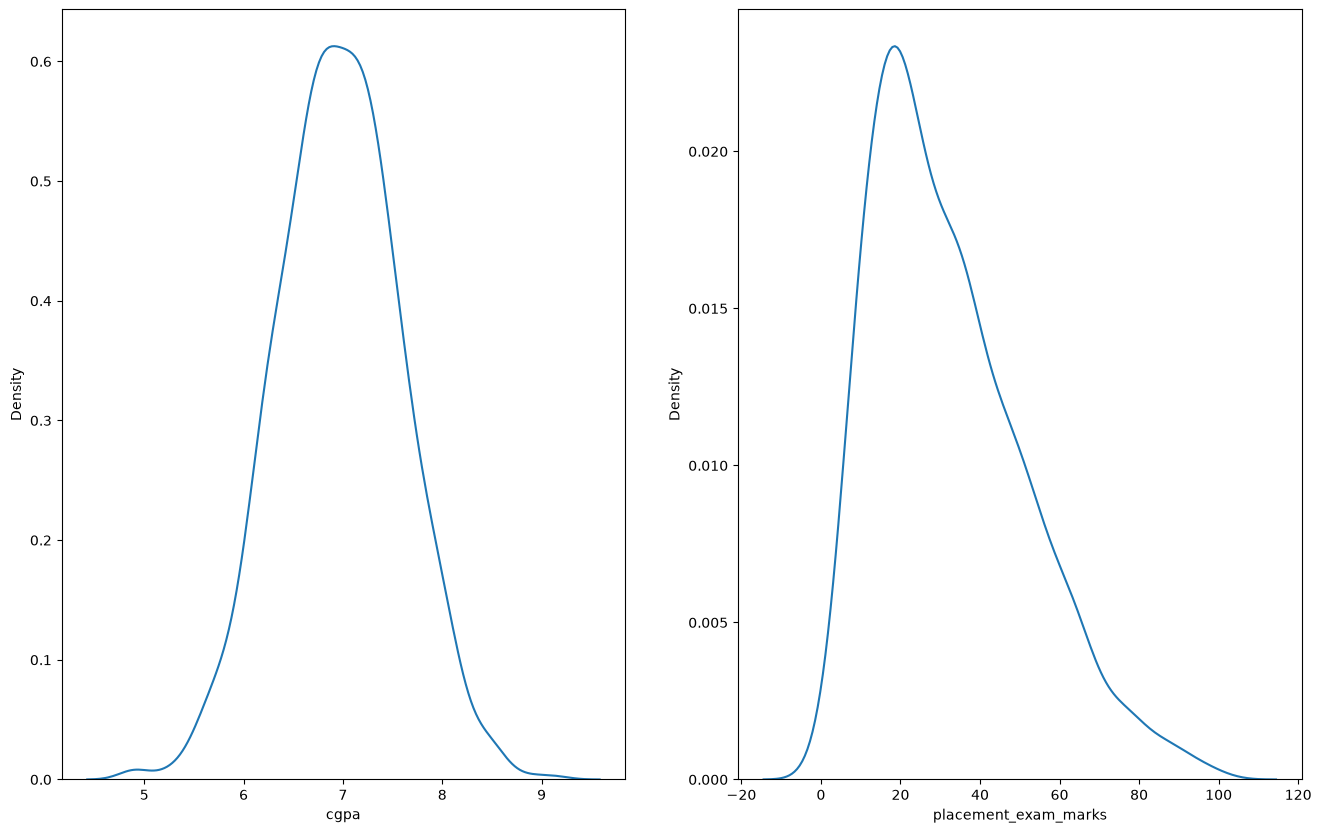

In [60]:
plt.figure(figsize=(16,10))

plt.subplot(1,2,1)
sns.distplot(df['cgpa'],hist=False)
plt.subplot(1,2,2)
sns.distplot(df['placement_exam_marks'],hist=False)
plt.show()

In [61]:
#cgpa normally distributed er upo z-score apply kora jbe

In [62]:
#for cgpa
print('mean',df['cgpa'].mean())
print('std',df['cgpa'].std())
print('min',df['cgpa'].min())
print('max',df['cgpa'].max())

mean 6.96124
std 0.6158978751323894
min 4.89
max 9.12


In [63]:
#boundary values
high=df['cgpa'].mean()+3*df['cgpa'].std()
low=df['cgpa'].mean()-3*df['cgpa'].std()

In [64]:
high

np.float64(8.808933625397168)

In [65]:
low

np.float64(5.113546374602832)

In [66]:
#finding the outliers
df[(df['cgpa']>high) | (df['cgpa']<low)]

,cgpa,placement_exam_marks,placed
485,4.92,44.0,1
995,8.87,44.0,1
996,9.12,65.0,1
997,4.89,34.0,0
999,4.90,10.0,1


In [67]:
#trimming

new_df= df[(df['cgpa']>=low) & (df['cgpa']<=high)]
new_df

,cgpa,placement_exam_marks,placed
0,7.19,26.0,1
1,7.46,38.0,1
2,7.54,40.0,1
3,6.42,8.0,1
4,7.23,17.0,0
...,...,...,...
991,7.04,57.0,0
992,6.26,12.0,0
993,6.73,21.0,1
994,6.48,63.0,0


In [68]:
#capping
df['cgpa']=np.where(
    df['cgpa']>high,
    high,
    np.where(
        df['cgpa']<low,
        low,
        df['cgpa']
    )
)

In [69]:
#np.where(condition, value_if_true, value_if_false)

In [70]:
df

,cgpa,placement_exam_marks,placed
0,7.190000,26.0,1
1,7.460000,38.0,1
2,7.540000,40.0,1
3,6.420000,8.0,1
4,7.230000,17.0,0
...,...,...,...
995,8.808934,44.0,1
996,8.808934,65.0,1
997,5.113546,34.0,0
998,8.620000,46.0,1


In [71]:
#iqr method --eita apply hbe placement_exam_marks ei column er upor karon eita normally distributed na

In [72]:
df['placement_exam_marks'].skew()

np.float64(0.8356419499466834)

In [73]:
df['placement_exam_marks'].describe()

count    1000.000000
mean       32.225000
std        19.130822
min         0.000000
25%        17.000000
50%        28.000000
75%        44.000000
max       100.000000
Name: placement_exam_marks, dtype: float64

<Axes: ylabel='placement_exam_marks'>

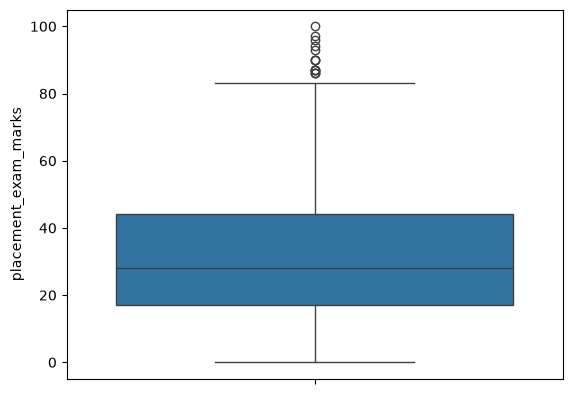

In [74]:
sns.boxplot(df['placement_exam_marks'])

In [75]:
#iqr calculation
per25=df['placement_exam_marks'].quantile(0.25)
per75=df['placement_exam_marks'].quantile(0.75)

iqr=per75-per25

In [76]:
iqr

np.float64(27.0)

In [77]:
upper=per75 + 1.5*iqr
lower=per25-1.5*iqr

In [78]:
upper

np.float64(84.5)

In [79]:
lower

np.float64(-23.5)

In [80]:
#outlier shob gula upper limit er baire box plot thk

df[df['placement_exam_marks']>upper]

,cgpa,placement_exam_marks,placed
9,7.75,94.0,1
40,6.60,86.0,1
61,7.51,86.0,0
134,6.33,93.0,0
162,7.80,90.0,0
283,7.09,87.0,0
290,8.38,87.0,0
311,6.97,87.0,1
324,6.64,90.0,0
630,6.56,96.0,1


In [81]:
#trimming

In [82]:
df_tm=df[df['placement_exam_marks']<upper]

In [83]:
df_tm

,cgpa,placement_exam_marks,placed
0,7.190000,26.0,1
1,7.460000,38.0,1
2,7.540000,40.0,1
3,6.420000,8.0,1
4,7.230000,17.0,0
...,...,...,...
995,8.808934,44.0,1
996,8.808934,65.0,1
997,5.113546,34.0,0
998,8.620000,46.0,1


<Axes: ylabel='placement_exam_marks'>

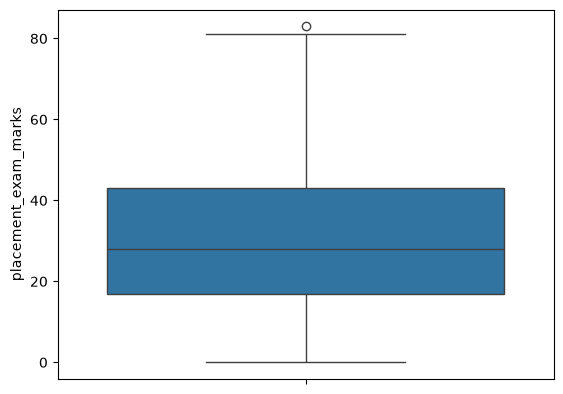

In [84]:
sns.boxplot(df_tm['placement_exam_marks'])

In [85]:
#capping


In [86]:
df_cap=df.copy()

In [87]:
df_cap

,cgpa,placement_exam_marks,placed
0,7.190000,26.0,1
1,7.460000,38.0,1
2,7.540000,40.0,1
3,6.420000,8.0,1
4,7.230000,17.0,0
...,...,...,...
995,8.808934,44.0,1
996,8.808934,65.0,1
997,5.113546,34.0,0
998,8.620000,46.0,1


In [88]:
df_cap['placement_exam_marks']=np.where(
    df_cap['placement_exam_marks']>upper,
    upper,
    np.where(
        df_cap['placement_exam_marks']<lower,
        lower,
        df_cap['placement_exam_marks']
    )
)

In [89]:
df_cap

,cgpa,placement_exam_marks,placed
0,7.190000,26.0,1
1,7.460000,38.0,1
2,7.540000,40.0,1
3,6.420000,8.0,1
4,7.230000,17.0,0
...,...,...,...
995,8.808934,44.0,1
996,8.808934,65.0,1
997,5.113546,34.0,0
998,8.620000,46.0,1


<Axes: ylabel='placement_exam_marks'>

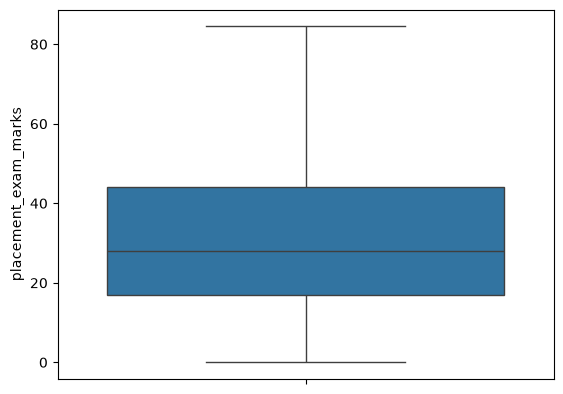

In [90]:
sns.boxplot(df_cap['placement_exam_marks'])

C:\Users\User\AppData\Local\Temp\ipykernel_16768\1601557921.py:1: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `kdeplot` (an axes-level function for kernel density plots).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(df_cap['placement_exam_marks'],hist=False)


<Axes: xlabel='placement_exam_marks', ylabel='Density'>

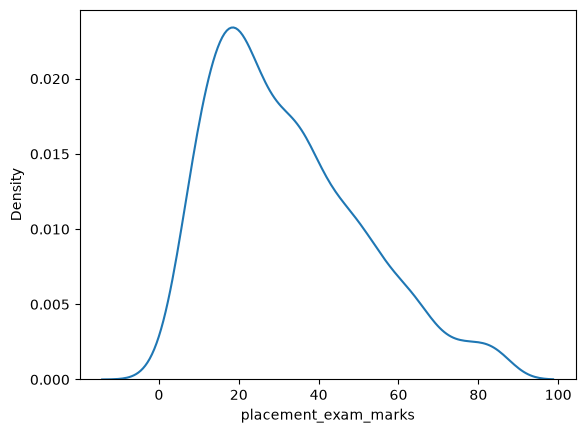

In [91]:
sns.distplot(df_cap['placement_exam_marks'],hist=False)

In [92]:
df_cap['placement_exam_marks'].describe()

count    1000.000000
mean       32.136500
std        18.865419
min         0.000000
25%        17.000000
50%        28.000000
75%        44.000000
max        84.500000
Name: placement_exam_marks, dtype: float64